In [2]:
import numpy as np
import matplotlib.pyplot as plt

def box_muller(n):
    m=int(np.ceil(n/2))
    U1=np.clip(np.random.rand(m),1e-10,1.0)
    U2=np.random.rand(m)
    Z1=np.sqrt(-2*np.log(U1))*np.cos(2*np.pi*U2)
    Z2=np.sqrt(-2*np.log(U1))*np.sin(2*np.pi*U2)
    return np.concatenate([Z1,Z2])[:n]

n=1000000

#3.1
X=box_muller(n)

In [3]:
#3.2
p_direct=np.mean(X>4)
print(f"Direct MC estimate of P(X>4): {p_direct:.8f}")

Direct MC estimate of P(X>4): 0.00002300


In [4]:
# 3.4
Z = box_muller(n)
Y = Z+4

#3.5

fX(y) = PDF of N(0,1) at y = (1/√2π) · exp(-y²/2)
fY(y) = PDF of N(4,1) at y = (1/√2π) · exp(-(y-4)²/2)

The 1/√2π cancels top and bottom, so:
w(y) = exp(-y²/2) / exp(-(y-4)²/2)

In [11]:
# 3.6
def likelihood_ratio(y):
    return np.exp(-0.5*y**2)/np.exp(-0.5*(y-4)**2)

w = likelihood_ratio(Y)
indicator = (Y>4)

p_IS = np.mean(indicator*w)
avg_weight_rare = np.sum(indicator*w)/np.sum(indicator)

print(f"3.6 - Importance Sampling estimate: {p_IS:.8f}")
print(f"Avg weight in rare region:{avg_weight_rare:.6f}")


3.6 - Importance Sampling estimate: 0.00003166
Avg weight in rare region:0.000063



Over 20 repetitions:
Direct MC mean: 0.00003245
Direct MC variance: 2.66e-11
IS mean: 0.00003168
IS variance: 3.14e-15


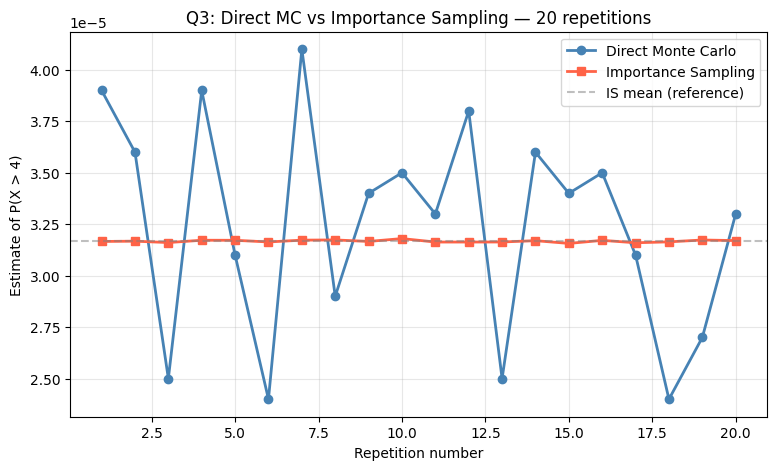

In [21]:
# 3.7
n_repeats = 20
direct_estimates = np.zeros(n_repeats)
IS_estimates = np.zeros(n_repeats)

for i in range(n_repeats):
    X_i = box_muller(n)
    direct_estimates[i] = np.mean(X_i>4)
    Z_i = box_muller(n)
    Y_i = Z_i+4
    w_i = likelihood_ratio(Y_i)
    IS_estimates[i] = np.mean((Y_i>4)*w_i)

print(f"\nOver 20 repetitions:")
print(f"Direct MC mean: {np.mean(direct_estimates):.8f}")
print(f"Direct MC variance: {np.var(direct_estimates):.2e}")
print(f"IS mean: {np.mean(IS_estimates):.8f}")
print(f"IS variance: {np.var(IS_estimates):.2e}")

plt.figure(figsize=(9, 5))
plt.plot(range(1, 21), direct_estimates, marker='o', color='steelblue',
         linewidth=2, label='Direct Monte Carlo')
plt.plot(range(1, 21), IS_estimates, marker='s', color='tomato',
         linewidth=2, label='Importance Sampling')
plt.axhline(y=np.mean(IS_estimates), color='gray', linestyle='--', alpha=0.5,
            label='IS mean (reference)')
plt.xlabel('Repetition number')
plt.ylabel('Estimate of P(X > 4)')
plt.title('Q3: Direct MC vs Importance Sampling — 20 repetitions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




The variance of Direct MC is ~8,000 times larger than Importance Sampling. Both methods give roughly the same mean answer (~0.0000317), but Direct MC's estimates scatter wildly across the 20 runs while IS gives almost the same answer every single time. That is exactly what the plot shows — the blue line (Direct MC) jumps up and down, while the red line (IS) stays almost perfectly flat.

Conclusion: For rare events, Importance Sampling is drastically more reliable. Direct MC wastes almost all its samples; IS concentrates samples exactly where they matter and corrects mathematically for doing so.